###Importação de bibliotecas

In [124]:
!pip install pandas nltk scikit-learn tensorflow

In [125]:
!pip install tokenizers

In [126]:
import pandas as pd
import numpy as np
import re
import nltk
import kagglehub
import random

from sklearn.model_selection import train_test_split

from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import tensorflow as tfs
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


###Download e carregamento do dataset

In [127]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [128]:
# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [129]:
df = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


###Pré-processamento dos dados

In [130]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [131]:
df['review'] = df['review'].str.lower()

In [132]:
df['review'] = df['review'].apply(lambda x: re.sub(r'<.*?>', '', x))

In [133]:
df['review'] = df['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

In [134]:
df['review'] = df['review'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [135]:
stop_words = set(stopwords.words('english'))

negacoes = {"not", "no", "never"}

stop_words = stop_words - negacoes

In [136]:
df['review'] = df['review'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

In [137]:
df["num_palavras"] = df["review"].apply(lambda x: len(x.split()))

###Análise do tamanho das reviews

In [138]:
reviews_200 = (df["num_palavras"] > 200).sum()

print("Reviews com mais de 200 palavras:", reviews_200)

Reviews com mais de 200 palavras: 7087


In [139]:
reviews_500 = (df["num_palavras"] > 500).sum()

print("Reviews com mais de 500 palavras:", reviews_500)

Reviews com mais de 500 palavras: 305


###Separação treino e teste

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.5,
    random_state=51
)

###Tokenização usando BPE

In [141]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()

In [142]:
trainer = BpeTrainer(
    vocab_size=20000,
    special_tokens=["[PAD]", "[UNK]"]
)

In [143]:
tokenizer.train_from_iterator(X_train, trainer)


In [144]:
train_tokens = [tokenizer.encode(text).ids for text in X_train]
test_tokens = [tokenizer.encode(text).ids for text in X_test]

###Converter textos em tokens

In [145]:
max_len = 200

train_tokens = [seq[:max_len] for seq in train_tokens]
test_tokens = [seq[:max_len] for seq in test_tokens]

###Limitar tamanho das sequências

In [146]:
X_train_pad = pad_sequences(train_tokens, maxlen=200, padding='post')
X_test_pad = pad_sequences(test_tokens, maxlen=200, padding='post')

In [147]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(25000, 200)
(25000, 200)


###Modelo LSTM

In [148]:
embedding_dim = 128
vocab_size = 20000

In [149]:
model = Sequential()

model.add(Input(shape=(max_len,)))

model.add(Embedding(vocab_size, embedding_dim, mask_zero=True))

model.add(LSTM(64, dropout=0.3))

model.add(Dense(1, activation='sigmoid'))

In [150]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [151]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [152]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

###Treinamento

In [153]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 205ms/step - accuracy: 0.7600 - loss: 0.4886 - val_accuracy: 0.8636 - val_loss: 0.3302
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 201ms/step - accuracy: 0.9295 - loss: 0.1984 - val_accuracy: 0.8052 - val_loss: 0.4131
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 202ms/step - accuracy: 0.9560 - loss: 0.1304 - val_accuracy: 0.8534 - val_loss: 0.4399


###Avaliação

In [154]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test)

print("Acurácia no teste:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8679 - loss: 0.3255
Acurácia no teste: 0.8683599829673767


###Curvas de erro

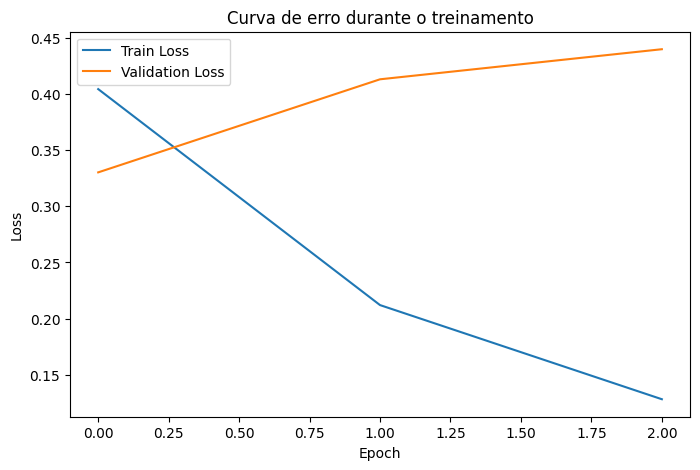

In [155]:


plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de erro durante o treinamento')

plt.legend()
plt.show()

###Curva de acurácia

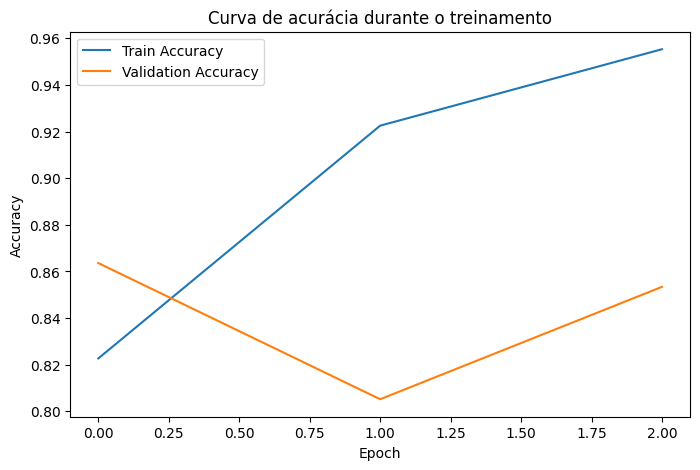

In [156]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Curva de acurácia durante o treinamento')

plt.legend()
plt.show()

###Predições

In [157]:
predictions = model.predict(X_test_pad)

782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step


In [158]:
pred_classes = (predictions > 0.5).astype(int)

In [159]:
random.seed(10)
indices = random.sample(range(len(y_test)), 5)

for i in indices:

    print("Review:")
    print(df['review'].iloc[i])

    print("Predição:", pred_classes[i][0])
    print("Rótulo real:", y_test.iloc[i])

    print("--------------")

Review:
muppet movie kermit miss piggy fozzie gonzo rowlf scooter camillia dr teeth floyd animal janice zoot college graduates decide bring successful college musical manhattan melodies broadway unfortunately no producer even meet muppets denied many producers scooter suggests muppets decide move however kermit still believes get show broadway finally lets everybody know sold show kermit gets amnesia others dont know isthis features many great scenes including live action sequence introduced muppet babies wedding sequence filled muppets including sesame street cast traveling matt fraggle rock scooter movie theatre usher scene rizzo rats cook breakfastmy complaint characters werent included sure many appear wedding significant roles bunsen beaker beauregard sweetums lips part electric mayhem movie like muppet shows last season great muppet caper miss piggys dog foo foo well rizzo rat also performed steve whitmire big part movie wasnt wellknown time
Predição: 0
Rótulo real: 0
-----------

###Experimentar embeddings pré-treinados GloVe

In [160]:
import numpy as np

def load_glove(path):

    glove = {}

    with open(path, encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove[word] = vector

    return glove


glove = load_glove("/glove.6B.100d.txt")
print("Palavras carregadas:", len(glove))

Palavras carregadas: 400000


In [171]:
embedding_dim = 100

In [162]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

vocab = tokenizer.get_vocab()

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in vocab.items():

    if i >= vocab_size:
        continue

    vector = glove.get(word.lower())

    if vector is not None:
        embedding_matrix[i] = vector

In [163]:
model_glove = Sequential()

model_glove.add(Input(shape=(max_len,)))

model_glove.add(
    Embedding(
        vocab_size,
        embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    )
)

model_glove.add(LSTM(64, dropout=0.3))

model_glove.add(Dense(1, activation='sigmoid'))

In [164]:
model_glove.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [165]:
history_glove = model_glove.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 131ms/step - accuracy: 0.6561 - loss: 0.6182 - val_accuracy: 0.7662 - val_loss: 0.5317
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.7484 - loss: 0.5207 - val_accuracy: 0.8140 - val_loss: 0.4236
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.7752 - loss: 0.4679 - val_accuracy: 0.8082 - val_loss: 0.4280
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 139ms/step - accuracy: 0.8126 - loss: 0.4186 - val_accuracy: 0.8394 - val_loss: 0.3692
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.8222 - loss: 0.3854 - val_accuracy: 0.8544 - val_loss: 0.3363
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 132ms/step - accuracy: 0.8331 - loss: 0.3673 - val_accuracy: 0.8454 - val_loss: 0.3594
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 137ms/step - accuracy: 0.8475 - loss: 0.3482 - val_accuracy: 0.8458 - val_loss: 0.3637


In [166]:
test_loss_glove, test_acc_glove = model_glove.evaluate(X_test_pad, y_test)

print("Acurácia no teste (GloVe):", test_acc_glove)

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8583 - loss: 0.3362
Acurácia no teste (GloVe): 0.8573600053787231


In [167]:
predictions_glove = model_glove.predict(X_test_pad)

pred_classes_glove = (predictions_glove > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step


In [168]:
random.seed(10)
indices = random.sample(range(len(y_test)), 5)

for i in indices:

    print("Review:")
    print(df['review'].iloc[i])

    print("Predição:", pred_classes[i][0])
    print("Rótulo real:", y_test.iloc[i])

    print("--------------")

Review:
muppet movie kermit miss piggy fozzie gonzo rowlf scooter camillia dr teeth floyd animal janice zoot college graduates decide bring successful college musical manhattan melodies broadway unfortunately no producer even meet muppets denied many producers scooter suggests muppets decide move however kermit still believes get show broadway finally lets everybody know sold show kermit gets amnesia others dont know isthis features many great scenes including live action sequence introduced muppet babies wedding sequence filled muppets including sesame street cast traveling matt fraggle rock scooter movie theatre usher scene rizzo rats cook breakfastmy complaint characters werent included sure many appear wedding significant roles bunsen beaker beauregard sweetums lips part electric mayhem movie like muppet shows last season great muppet caper miss piggys dog foo foo well rizzo rat also performed steve whitmire big part movie wasnt wellknown time
Predição: 0
Rótulo real: 0
-----------

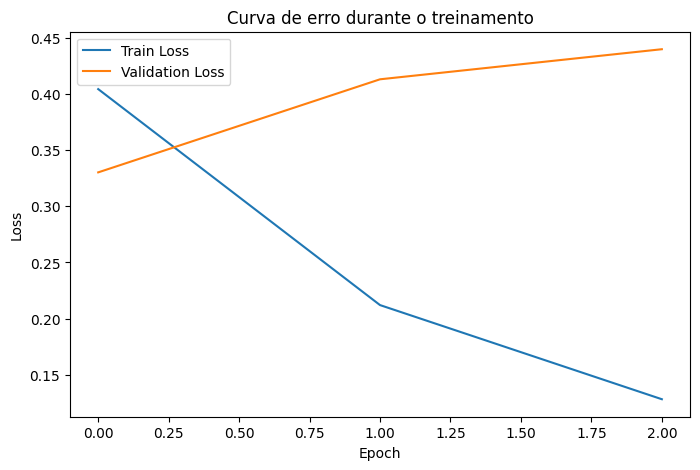

In [169]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de erro durante o treinamento')

plt.legend()
plt.show()

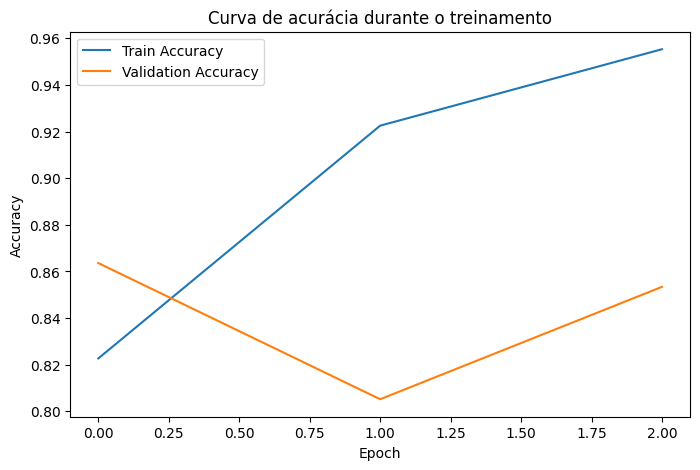

In [170]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Curva de acurácia durante o treinamento')

plt.legend()
plt.show()